In [1]:
from qibo.models.dbi.double_bracket import DoubleBracketIteration, DoubleBracketGeneratorType, DoubleBracketScheduling, DoubleBracketCostFunction
from qibo.models.dbi.utils import generate_pauli_operator_dict, decompose_into_pauli_basis, params_to_diagonal_operator, ParameterizationTypes
from copy import deepcopy
from qibo.models.dbi.utils_dbr_strategies import gradient_descent, gradient_descent_step
import numpy as np
from qibo import set_backend, hamiltonians
from qibo.hamiltonians import Hamiltonian
from qibo.quantum_info import random_hermitian
import matplotlib.pyplot as plt

In [2]:
def visualize_matrix(matrix, title=""):
    """Visualize hamiltonian in a heatmap form."""
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    try:
        im = ax.imshow(np.absolute(matrix), cmap="inferno")
    except TypeError:
        im = ax.imshow(np.absolute(matrix.get()), cmap="inferno")
    fig.colorbar(im, ax=ax)

def s_hist_to_plot(s_hist):
    # convert list of step durations taken to plotable
    s_plot = [0] * len(s_hist)
    for i in range(len(s_hist)):
        if i != 0:
            s_plot[i] = s_plot[i-1] + s_hist[i]
    return s_plot

## Random hamiltonian

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
[Qibo 0.2.9|INFO|2024-06-05 09:24:34]: Using qibojit (numba) backend on /CPU:0


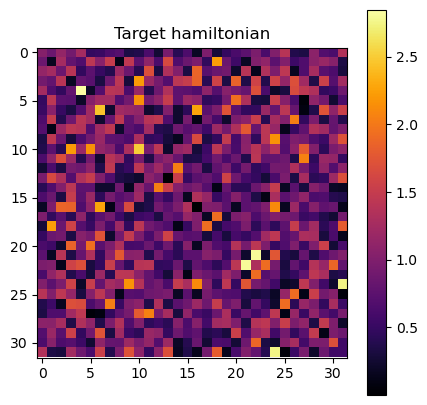

In [3]:
# set the qibo backend (we suggest qibojit if N >= 20)
set_backend("qibojit", platform="numba")

# hamiltonian parameters
nqubits = 5
seed = 10

# define the hamiltonian
h0 = random_hermitian(2**nqubits, seed=seed)
dbi = DoubleBracketIteration(
    Hamiltonian(nqubits, h0),
    mode=DoubleBracketGeneratorType.single_commutator,
    scheduling=DoubleBracketScheduling.hyperopt,
    cost=DoubleBracketCostFunction.off_diagonal_norm
)
# vosualize the matrix
visualize_matrix(dbi.h.matrix, title="Target hamiltonian")

In [4]:
# initialize Pauli-basis
pauli_operator_dict = generate_pauli_operator_dict(nqubits)
pauli_operators = list(pauli_operator_dict.values())
d_coef_pauli = np.ones(nqubits)

[Qibo 0.2.9|WARNING|2024-06-05 09:24:35]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 09:24:35]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 09:24:35]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 09:24:35]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.9|WARNING|2024-06-05 09:24:35]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


In [7]:
import time

In [25]:
# Use training to find a better d
train_space = np.linspace(1,1001, 8)
a = []
t = []
for train_epochs in train_space:
    t0 = time.time()
    d_train_coef, d_train, s_train = gradient_descent_step(dbi, int(train_epochs), d_coef_pauli, ParameterizationTypes.pauli, pauli_operator_dict)
    print(dbi.loss(s_train, d_train))
    a.append(dbi.loss(s_train, d_train))
    print("time:", time.time()-t0)
    t.append(time.time()-t0)

28.206198951111503
time: 0.11498689651489258
28.144041319221383
time: 0.439410924911499
28.065227127350624
time: 0.7849717140197754
27.930760882541414
time: 1.1270809173583984
27.769688464665336
time: 1.4545462131500244
27.44839471035425
time: 1.829698085784912
27.090730050419577
time: 2.202849864959717
26.941092910253285
time: 2.6179568767547607


In [26]:
max_evals_space = np.linspace(100, 500, 5)
b = []
tt = []
for max_evals in max_evals_space:
    t0 = time.time()
    d_train_coef, d_train, s_train = gradient_descent(dbi, d_coef_pauli, ParameterizationTypes.pauli, pauli_operator_dict, max_evals=max_evals)
    print(dbi.loss(s_train, d_train))
    b.append(dbi.loss(s_train, d_train))
    print("time:", time.time()-t0)
    tt.append(time.time()-t0)

28.171401276160193
time: 0.1944119930267334
28.191844384679904
time: 0.3255119323730469
28.166377416035623
time: 0.47450780868530273
28.185332757113756
time: 0.6087417602539062
28.16638555335546
time: 0.7880942821502686


Text(0, 0.5, 'Off-diagonal norm')

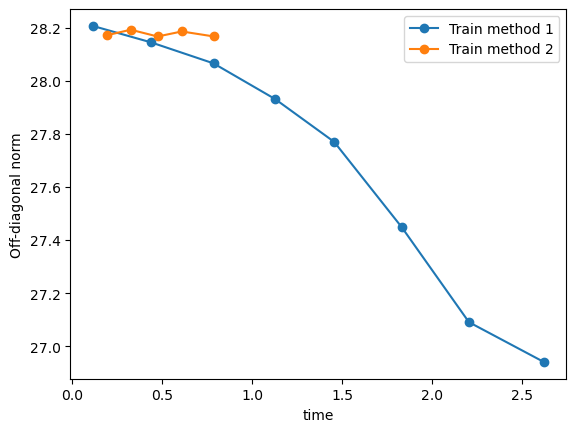

In [29]:
plt.plot(t, a, label='Train method 1', marker='o')
plt.plot(tt, b, label='Train method 2', marker='o')
plt.legend()
plt.xlabel('time')
plt.ylabel('Off-diagonal norm')